In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Chart style set kar rahe hain taaki graphs achhe dikhein
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries Imported")

Libraries Imported


In [3]:
df=pd.read_csv("heatwave_thermal_stress_dataset.csv")

df.head()

,date,temperature_c,humidity_pct,wind_speed_kmh,solar_radiation_w_m2,pressure_hpa,rainfall_mm,heat_index_c,wbgt_c,apparent_temperature_c,thermal_stress_score,thermal_stress_level,heatwave,risk_level,risk_score
0,2020-01-01 00:00:00,37.5,32.6,4.3,423.0,1018.7,0.2,38.6,35.3,39.6,27.41,Low,0,Yellow,53.1
1,2020-01-01 06:00:00,33.0,34.2,6.1,599.0,1007.5,0.3,34.0,31.5,33.5,26.78,Low,0,Yellow,40.0
2,2020-01-01 12:00:00,38.5,54.6,3.4,777.0,1000.4,2.5,40.8,37.3,46.1,37.00,Moderate,0,Orange,59.4
3,2020-01-01 18:00:00,44.7,41.5,7.1,620.0,991.8,0.4,45.9,42.3,52.2,33.86,Moderate,1,Orange,74.0
4,2020-01-02 00:00:00,32.4,38.6,12.8,623.0,992.7,0.5,32.8,31.1,32.1,26.52,Low,0,Yellow,36.6


In [4]:
print("Missing values per column:\n", df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())
df.describe()

Missing values per column:
 date                      0
temperature_c             0
humidity_pct              0
wind_speed_kmh            0
solar_radiation_w_m2      0
pressure_hpa              0
rainfall_mm               0
heat_index_c              0
wbgt_c                    0
apparent_temperature_c    0
thermal_stress_score      0
thermal_stress_level      0
heatwave                  0
risk_level                0
risk_score                0
dtype: int64

Duplicate rows: 0


,temperature_c,humidity_pct,wind_speed_kmh,solar_radiation_w_m2,pressure_hpa,rainfall_mm,heat_index_c,wbgt_c,apparent_temperature_c,thermal_stress_score,heatwave,risk_score
count,5000.00000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,34.04050,57.11160,11.070440,549.680400,1005.021800,1.499920,35.567800,33.185200,38.530420,32.029698,0.167000,44.521480
std,6.82577,21.41587,7.121865,241.990918,9.820007,1.484105,6.948608,6.188225,11.679253,6.575909,0.373013,19.750763
min,18.00000,20.00000,0.100000,50.000000,970.000000,0.000000,15.400000,17.300000,9.500000,10.830000,0.000000,0.000000
25%,29.40000,38.90000,5.700000,377.000000,998.200000,0.400000,30.800000,28.900000,30.300000,27.340000,0.000000,30.900000
50%,34.10000,56.90000,9.500000,548.000000,1005.100000,1.000000,35.700000,33.300000,37.800000,32.175000,0.000000,44.900000
75%,38.70000,75.40000,14.800000,721.000000,1011.600000,2.100000,40.200000,37.300000,45.600000,36.842500,0.000000,57.700000
max,50.00000,95.00000,35.000000,1100.000000,1037.200000,10.800000,54.000000,49.300000,82.100000,51.680000,1.000000,97.100000


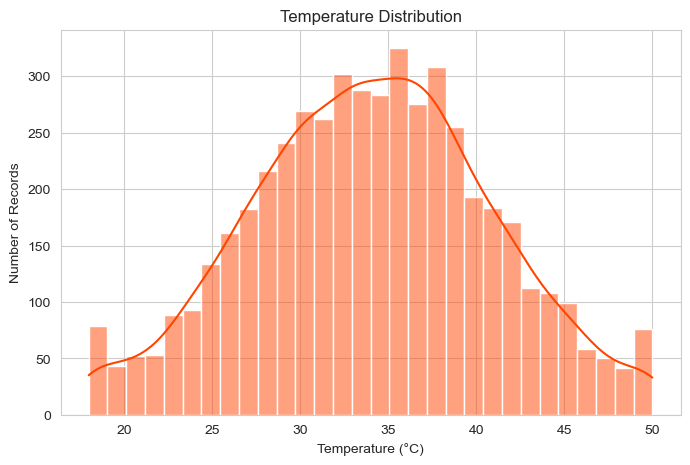

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df["temperature_c"], bins=30, kde=True, color="orangered")
plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Number of Records")
plt.show()

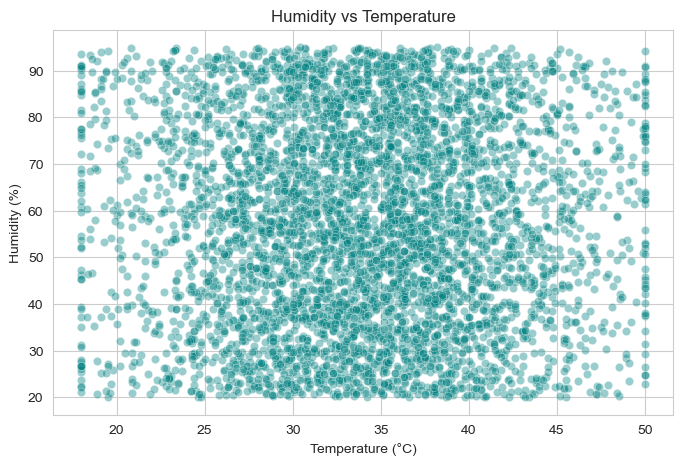

In [6]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="temperature_c", y="humidity_pct", alpha=0.4, color="teal")
plt.title("Humidity vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_19412\3037491755.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_hot, x="temperature_c", y="date", palette="Reds_r")


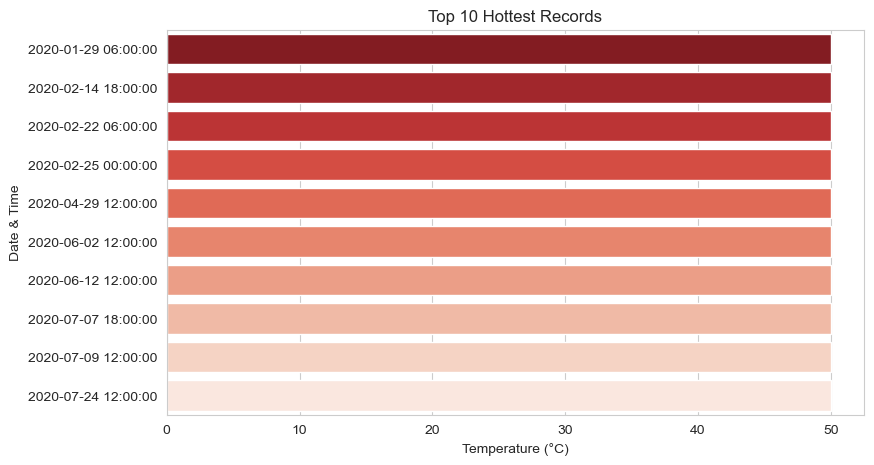

In [7]:
top_hot = df.nlargest(10, "temperature_c")[["date", "temperature_c"]]

plt.figure(figsize=(9,5))
sns.barplot(data=top_hot, x="temperature_c", y="date", palette="Reds_r")
plt.title("Top 10 Hottest Records")
plt.xlabel("Temperature (°C)")
plt.ylabel("Date & Time")
plt.show()

## Heat Index Calculation

In [8]:
def calculate_heat_index(temp_c, humidity):
    T = temp_c * 9/5 + 32 
    R = humidity

    HI = (-42.379 + 2.04901523*T + 10.14333127*R - 0.22475541*T*R
          - 0.00683783*T*T - 0.05481717*R*R + 0.00122874*T*T*R
          + 0.00085282*T*R*R - 0.00000199*T*T*R*R)

    return (HI - 32) * 5/9  

In [9]:
df[["temperature_c", "humidity_pct", "heat_index_c"]].head()

,temperature_c,humidity_pct,heat_index_c
0,37.5,32.6,38.6
1,33.0,34.2,34.0
2,38.5,54.6,40.8
3,44.7,41.5,45.9
4,32.4,38.6,32.8


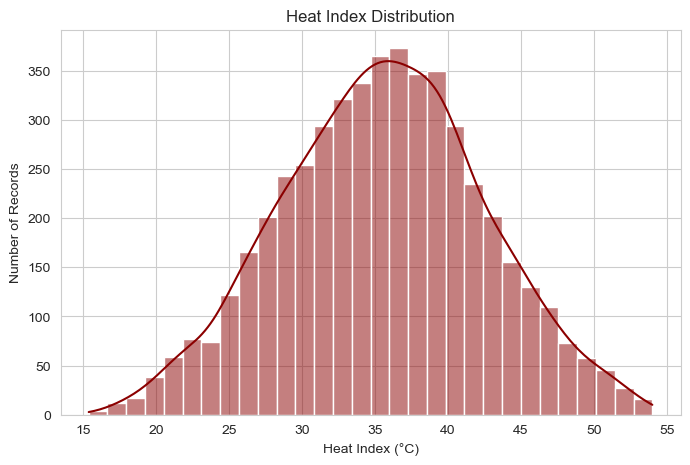

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["heat_index_c"], bins=30, kde=True, color="darkred")
plt.title("Heat Index Distribution")
plt.xlabel("Heat Index (°C)")
plt.ylabel("Number of Records")
plt.show()

 ## Risk Label Creation (Rule-Based)

In [11]:
def get_risk_level(heat_index):
    if heat_index < 32:
        return "Green"
    elif heat_index < 40:
        return "Yellow"
    elif heat_index < 48:
        return "Orange"
    else:
        return "Red"

def get_risk_score(heat_index):
    score = (heat_index - 20) / (55 - 20) * 100
    return round(np.clip(score, 0, 100), 1)

df["risk_level"] = df["heat_index_c"].apply(get_risk_level)
df["risk_score"] = df["heat_index_c"].apply(get_risk_score)

df[["temperature_c", "humidity_pct", "heat_index_c", "risk_level", "risk_score"]].sample(8)

,temperature_c,humidity_pct,heat_index_c,risk_level,risk_score
1225,33.1,69.8,35.7,Yellow,44.9
2876,27.4,24.8,28.1,Green,23.1
3077,37.9,28.3,38.0,Yellow,51.4
3296,45.7,27.9,44.8,Orange,70.9
4761,38.7,82.0,42.7,Orange,64.9
1401,37.8,35.6,37.2,Yellow,49.1
3119,45.6,39.2,45.8,Orange,73.7
1069,36.4,36.3,38.0,Yellow,51.4


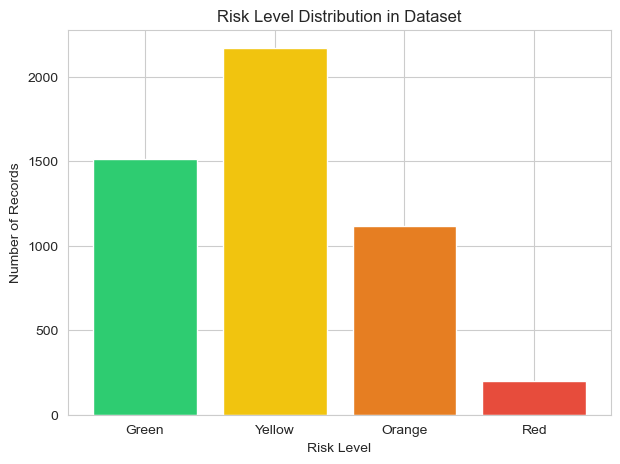

In [12]:
risk_order = ["Green", "Yellow", "Orange", "Red"]
risk_colors = {"Green": "#2ecc71", "Yellow": "#f1c40f", "Orange": "#e67e22", "Red": "#e74c3c"}

plt.figure(figsize=(7,5))
counts = df["risk_level"].value_counts().reindex(risk_order)
plt.bar(counts.index, counts.values, color=[risk_colors[r] for r in counts.index])
plt.title("Risk Level Distribution in Dataset")
plt.xlabel("Risk Level")
plt.ylabel("Number of Records")
plt.show()

##  ML Model — Risk Level Predict

In [13]:
feature_cols = ["temperature_c", "humidity_pct", "wind_speed_kmh", "solar_radiation_w_m2"]

X = df[feature_cols]

le = LabelEncoder()
y = le.fit_transform(df["risk_level"])

print("Risk classes:", list(le.classes_))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Risk classes: ['Green', 'Orange', 'Red', 'Yellow']
Training samples: 4000, Testing samples: 1000


In [14]:
model = RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f" Model Accuracy: {acc*100:.2f}%\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

 Model Accuracy: 96.60%

Classification Report:

              precision    recall  f1-score   support

       Green       0.99      0.96      0.97       303
      Orange       0.96      0.96      0.96       224
         Red       0.94      0.87      0.91        39
      Yellow       0.96      0.98      0.97       434

    accuracy                           0.97      1000
   macro avg       0.96      0.94      0.95      1000
weighted avg       0.97      0.97      0.97      1000



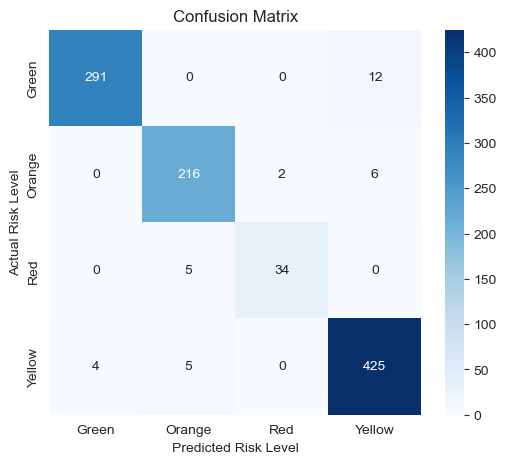

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Risk Level")
plt.ylabel("Actual Risk Level")
plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_19412\2838545771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance.values, y=importance.index, palette="viridis")


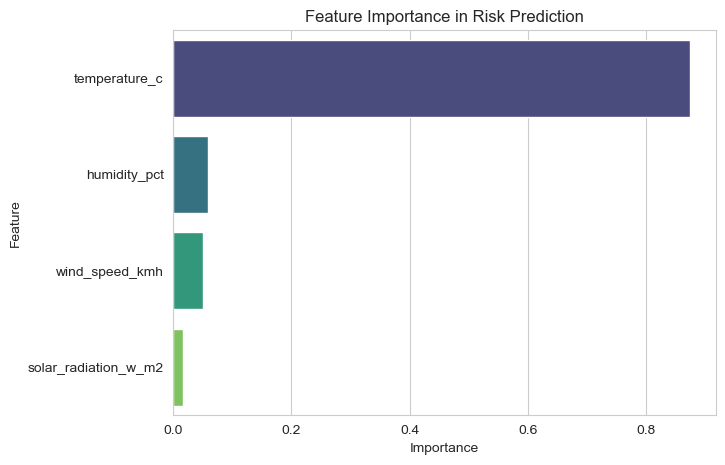

temperature_c           0.875086
humidity_pct            0.059443
wind_speed_kmh          0.049750
solar_radiation_w_m2    0.015721
dtype: float64


In [16]:
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(7,5))
sns.barplot(x=importance.values, y=importance.index, palette="viridis")
plt.title("Feature Importance in Risk Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

print(importance)

## Rule-Based vs ML Model — Comparison

In [17]:
comparison = pd.DataFrame({
    "Approach": ["Rule-Based (Heat Index formula)", "ML Model (Random Forest)"],
    "Input Used": ["heat_index_c (formula se)", "raw weather sensors only"],
    "Accuracy on Test Data": ["100% (by definition)", f"{acc*100:.2f}%"]
})
comparison

,Approach,Input Used,Accuracy on Test Data
0,Rule-Based (Heat Index formula),heat_index_c (formula se),100% (by definition)
1,ML Model (Random Forest),raw weather sensors only,96.60%


## Explainable Prediction Function

In [ ]:
def predict_heat_risk(temperature_c, humidity_percent, wind_speed_kmh, solar_radiation):
   
    heat_index = calculate_heat_index(temperature_c, humidity_percent)


    risk_level = get_risk_level(heat_index)
    risk_score = get_risk_score(heat_index)


    reasons = []
    if temperature_c >= 40:
        reasons.append("Temperature very high ")
    elif temperature_c >= 35:
        reasons.append("Temperature high ")

    if humidity_percent >= 60:
        reasons.append("Risk")

    if wind_speed_kmh < 5:
        reasons.append("Wind speed kam hai, isliye garmi zyada feel hogi")

    if solar_radiation >= 700:
        reasons.append("Solar radiation bahut zyada hai, direct dhoop mein risk badh jaata hai")

    if not reasons:
        reasons.append("Weather conditions abhi normal range mein hain")

    action_map = {
        "Green": "Normal precautions lein — paani peete rahein.",
        "Yellow": "Paani piyein aur direct dhoop se bachein.",
        "Orange": "Dopahar 12 PM se 4 PM tak outdoor kaam kam karein.",
        "Red": "Turant alert bhejein, ORS/paani point arrange karein, health centre ready rakhein aur outdoor kaam avoid karein."
    }
    recommended_action = action_map[risk_level]

    return {
        "risk_level": risk_level,
        "risk_score": risk_score,
        "heat_index_c": round(heat_index, 1),
        "top_reasons": reasons,
        "recommended_action": recommended_action
    }

print("predict_heat_risk() function is ready ")

✅ predict_heat_risk() function ready hai!


## Demo Predictions

In [ ]:
# Case 1: Normal Day (Green expected)
result1 = predict_heat_risk(temperature_c=35, humidity_percent=30, wind_speed_kmh=12, solar_radiation=350)
print("🌤️ Case 1: Normal Day")
print(result1)

🌤️ Case 1: Normal Day
{'risk_level': 'Red', 'risk_score': np.float64(100.0), 'heat_index_c': 202.8, 'top_reasons': ['Temperature bahut high hai'], 'recommended_action': 'Turant alert bhejein, ORS/paani point arrange karein, health centre ready rakhein aur outdoor kaam avoid karein.'}


In [22]:
# Case 2: Hot Day (Yellow expected)
result2 = predict_heat_risk(temperature_c=35, humidity_percent=50, wind_speed_kmh=8, solar_radiation=600)
print("☀️ Case 2: Hot Day")
print(result2)

☀️ Case 2: Hot Day
{'risk_level': 'Orange', 'risk_score': np.float64(59.1), 'heat_index_c': 40.7, 'top_reasons': ['Temperature high hai'], 'recommended_action': 'Dopahar 12 PM se 4 PM tak outdoor kaam kam karein.'}


In [23]:
# Case 3: Very Hot & Humid Day (Orange expected)
result3 = predict_heat_risk(temperature_c=40, humidity_percent=65, wind_speed_kmh=4, solar_radiation=750)
print("🔥 Case 3: Very Hot & Humid Day")
print(result3)

🔥 Case 3: Very Hot & Humid Day
{'risk_level': 'Red', 'risk_score': np.float64(100.0), 'heat_index_c': 67.1, 'top_reasons': ['Temperature bahut high hai', 'Humidity zyada hone se body ko thanda rehna difficult hai', 'Wind speed kam hai, isliye garmi zyada feel hogi', 'Solar radiation bahut zyada hai, direct dhoop mein risk badh jaata hai'], 'recommended_action': 'Turant alert bhejein, ORS/paani point arrange karein, health centre ready rakhein aur outdoor kaam avoid karein.'}


In [24]:
# Case 4: Extreme Hot Day (Red expected)
result4 = predict_heat_risk(temperature_c=46, humidity_percent=70, wind_speed_kmh=2, solar_radiation=900)
print("🚨 Case 4: Extreme Hot Day")
print(result4)

🚨 Case 4: Extreme Hot Day
{'risk_level': 'Red', 'risk_score': np.float64(100.0), 'heat_index_c': 106.0, 'top_reasons': ['Temperature bahut high hai', 'Humidity zyada hone se body ko thanda rehna difficult hai', 'Wind speed kam hai, isliye garmi zyada feel hogi', 'Solar radiation bahut zyada hai, direct dhoop mein risk badh jaata hai'], 'recommended_action': 'Turant alert bhejein, ORS/paani point arrange karein, health centre ready rakhein aur outdoor kaam avoid karein.'}


In [25]:
demo_df = pd.DataFrame([result1, result2, result3, result4])
demo_df.insert(0, "case", ["Normal Day", "Hot Day", "Very Hot & Humid", "Extreme Hot Day"])
demo_df

,case,risk_level,risk_score,heat_index_c,top_reasons,recommended_action
0,Normal Day,Green,22.9,28.0,[Weather conditions abhi normal range mein hain],Normal precautions lein — paani peete rahein.
1,Hot Day,Orange,59.1,40.7,[Temperature high hai],Dopahar 12 PM se 4 PM tak outdoor kaam kam kar...
2,Very Hot & Humid,Red,100.0,67.1,"[Temperature bahut high hai, Humidity zyada ho...","Turant alert bhejein, ORS/paani point arrange ..."
3,Extreme Hot Day,Red,100.0,106.0,"[Temperature bahut high hai, Humidity zyada ho...","Turant alert bhejein, ORS/paani point arrange ..."


In [26]:
df.to_csv("heatwave_sample_data.csv", index=False)
print("✅ Dataset save: heatwave_sample_data.csv")
print("Shape:", df.shape)
df.head()

✅ Dataset save: heatwave_sample_data.csv
Shape: (5000, 15)


,date,temperature_c,humidity_pct,wind_speed_kmh,solar_radiation_w_m2,pressure_hpa,rainfall_mm,heat_index_c,wbgt_c,apparent_temperature_c,thermal_stress_score,thermal_stress_level,heatwave,risk_level,risk_score
0,2020-01-01 00:00:00,37.5,32.6,4.3,423.0,1018.7,0.2,38.6,35.3,39.6,27.41,Low,0,Yellow,53.1
1,2020-01-01 06:00:00,33.0,34.2,6.1,599.0,1007.5,0.3,34.0,31.5,33.5,26.78,Low,0,Yellow,40.0
2,2020-01-01 12:00:00,38.5,54.6,3.4,777.0,1000.4,2.5,40.8,37.3,46.1,37.00,Moderate,0,Orange,59.4
3,2020-01-01 18:00:00,44.7,41.5,7.1,620.0,991.8,0.4,45.9,42.3,52.2,33.86,Moderate,1,Orange,74.0
4,2020-01-02 00:00:00,32.4,38.6,12.8,623.0,992.7,0.5,32.8,31.1,32.1,26.52,Low,0,Yellow,36.6


## Save model

In [27]:
import joblib
joblib.dump(model, "heat_risk_model.pkl")

['heat_risk_model.pkl']